<a href="https://colab.research.google.com/github/Sanataniitb/autoimmune-disease/blob/main/notebooks/original/T1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_excel("/content/drive/MyDrive/Seminar_Sanatan/MTP/ML Codes/T1D ML Input manual feature 167.xlsx")


In [ ]:
data.shape

(166, 181)

In [ ]:
data.head()

,Gene,lib1503,lib1582,lib3218,lib3220,lib3223,lib3240,lib3243,lib3254,lib3265,...,healthy_34,healthy_35,healthy_36,healthy_37,healthy_38,healthy_39,healthy_40,healthy_41,healthy_42,healthy_43
0,AAK1,1587,1455,397,1059,1148,1098,1463,1122,1297,...,452,85,399,437,515,203,683,393,644,192
1,AK6,138,90,25,104,106,118,160,97,100,...,1261,477,1823,1133,1224,1041,1950,714,1941,950
2,ANP32D,28,30,1,33,25,31,32,24,23,...,0,0,0,0,0,0,0,0,0,0
3,ANXA9,63,92,14,103,96,72,93,71,116,...,34,10,25,18,0,6,35,7,36,8
4,APC2,26,48,9,29,24,36,40,33,27,...,1,0,1,3,0,0,3,0,0,0


In [ ]:
cols=list(data.Gene)
#cols=list(data['Unnamed: 0'])

In [ ]:
data=data.T

In [ ]:
data.columns=cols

In [ ]:
data["target"]=data.index

In [ ]:
data.reset_index(inplace=True)

In [ ]:
data.head()

,index,AAK1,AK6,ANP32D,ANXA9,APC2,ARF6,BAX,C18orf32,C1QC,...,U2AF1,WDR73,XBP1,ZDHHC20,ZFPL1,ZFPL1,ZNF337,ZNF362,ZSCAN32,target
0,Gene,AAK1,AK6,ANP32D,ANXA9,APC2,ARF6,BAX,C18orf32,C1QC,...,U2AF1,WDR73,XBP1,ZDHHC20,ZFPL1,ZFPL1,ZNF337,ZNF362,ZSCAN32,Gene
1,lib1503,1587,138,28,63,26,2856,535,94,0,...,3,19,0,1530,27,642,9,412,23,lib1503
2,lib1582,1455,90,30,92,48,2543,457,89,1,...,5,25,0,1220,26,458,25,420,14,lib1582
3,lib3218,397,25,1,14,9,591,157,29,0,...,0,9,0,203,9,158,4,83,3,lib3218
4,lib3220,1059,104,33,103,29,2418,1096,87,16,...,6,32,0,925,45,409,13,493,7,lib3220


In [ ]:
data.drop(index=data.index[0],axis=0,inplace=True)

In [ ]:
def val(row):
    if row[0]=="l":
        return 1
    else:
        return 0

In [ ]:
data["target"]=data.target.apply(val)

In [ ]:
data.head()

,index,AAK1,AK6,ANP32D,ANXA9,APC2,ARF6,BAX,C18orf32,C1QC,...,U2AF1,WDR73,XBP1,ZDHHC20,ZFPL1,ZFPL1,ZNF337,ZNF362,ZSCAN32,target
1,lib1503,1587,138,28,63,26,2856,535,94,0,...,3,19,0,1530,27,642,9,412,23,1
2,lib1582,1455,90,30,92,48,2543,457,89,1,...,5,25,0,1220,26,458,25,420,14,1
3,lib3218,397,25,1,14,9,591,157,29,0,...,0,9,0,203,9,158,4,83,3,1
4,lib3220,1059,104,33,103,29,2418,1096,87,16,...,6,32,0,925,45,409,13,493,7,1
5,lib3223,1148,106,25,96,24,2640,910,93,7,...,5,27,0,1036,40,419,15,439,7,1


In [ ]:
data.drop("index",axis=1,inplace=True)

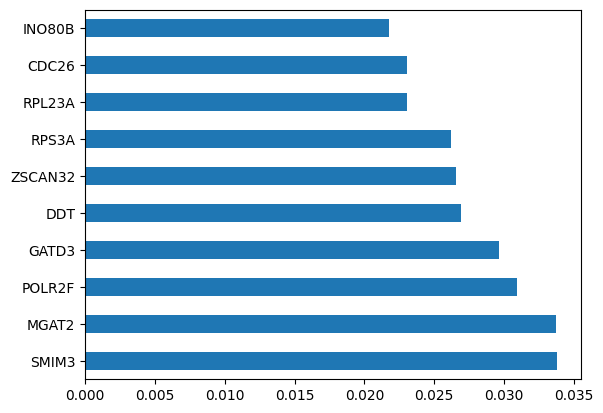

In [ ]:
import numpy as np

X = data.iloc[:,0:-1]  #independent columns
y = data.iloc[:,-1]    #target column i.e price range
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model = ExtraTreesClassifier()
model.fit(X,y)
#print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
important_feature=list(feat_importances[feat_importances>0.003].index)

In [ ]:
l=["HLA-DQB1",
"INS",
"PTPN22",
"CTLA4",
"IL2RA",
"IFIH1",
"ERBB3",
"CLEC16A",
"SUMO4",
"HLA-DRB1"]
important_feature=important_feature+l

In [ ]:
len(important_feature)

86

In [ ]:
x=data.drop("target",axis=1)

In [ ]:
x=x[important_feature]

In [ ]:
x.head()

,ANP32D,ANXA9,APC2,BAX,CCDC117,CD80,CDC26,CERKL,CIDEB,CKLF,...,HLA-DQB1,INS,PTPN22,CTLA4,IL2RA,IFIH1,ERBB3,CLEC16A,SUMO4,HLA-DRB1
1,28,63,26,535,47,7,23,1809,0,4,...,468,0,667,95,118,522,9,404,0,3270
2,30,92,48,457,65,2,21,1175,0,6,...,543,0,416,96,110,416,8,488,0,3554
3,1,14,9,157,9,0,4,256,0,4,...,99,0,95,19,27,111,1,101,1,1174
4,33,103,29,1096,19,1,24,1304,0,11,...,3153,0,384,68,103,485,4,397,1,9537
5,25,96,24,910,28,1,9,1676,0,5,...,826,0,500,80,126,563,4,398,1,5042


In [ ]:
import numpy as np

def standardize_features_by_class(X, y):
    classes = np.unique(y)
    standardized_features = []

    for cls in classes:
        class_features = X[y == cls]
        class_means = np.mean(class_features, axis=0)
        class_stds = np.std(class_features, axis=0)
        standardized_class_features = (class_features - class_means) / (class_stds+1)
        standardized_features.append(standardized_class_features)
    standardized_X = np.concatenate(standardized_features)

    return standardized_X

standardized_X = standardize_features_by_class(x, y)

In [ ]:
x.head()

,ANP32D,ANXA9,APC2,BAX,CCDC117,CD80,CDC26,CERKL,CIDEB,CKLF,...,HLA-DQB1,INS,PTPN22,CTLA4,IL2RA,IFIH1,ERBB3,CLEC16A,SUMO4,HLA-DRB1
1,28,63,26,535,47,7,23,1809,0,4,...,468,0,667,95,118,522,9,404,0,3270
2,30,92,48,457,65,2,21,1175,0,6,...,543,0,416,96,110,416,8,488,0,3554
3,1,14,9,157,9,0,4,256,0,4,...,99,0,95,19,27,111,1,101,1,1174
4,33,103,29,1096,19,1,24,1304,0,11,...,3153,0,384,68,103,485,4,397,1,9537
5,25,96,24,910,28,1,9,1676,0,5,...,826,0,500,80,126,563,4,398,1,5042


In [ ]:
y=data["target"]

In [ ]:
y.head()

1    1
2    1
3    1
4    1
5    1
Name: target, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( standardized_X, y, test_size=0.23, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import svm

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
y_tpred = classifier.predict(X_train)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[ 3  6]
 [ 4 29]]


In [ ]:
from sklearn.metrics import accuracy_score
print ("Accuracy train : ", accuracy_score(y_train, y_tpred))
print ("Accuracy test: ", accuracy_score(y_test, y_pred))

Accuracy train :  0.9420289855072463
Accuracy test:  0.7619047619047619


In [ ]:
from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

f1_score train :  0.9167922821826952
f1_score test:  0.6139705882352942


Text(50.722222222222214, 0.5, 'actual')

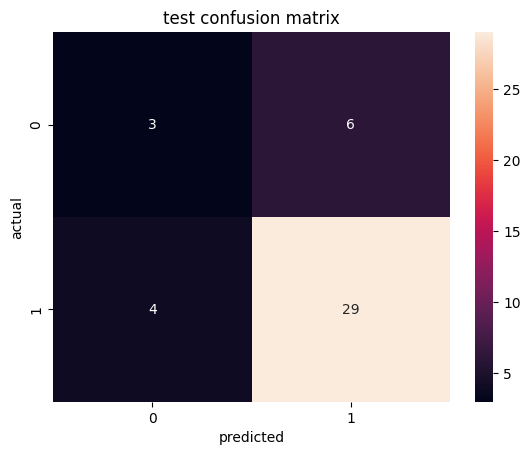

In [ ]:
import seaborn as sn
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

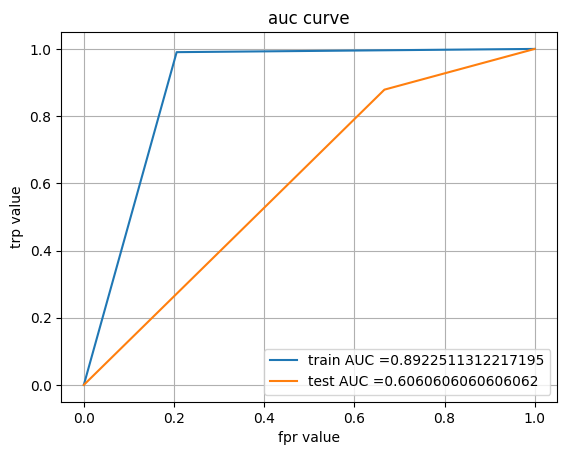

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

0.7536231884057971
0.7857142857142857
F1 score train :  0.4297520661157025
F1 score test:  0.44


Text(50.722222222222214, 0.5, 'actual')

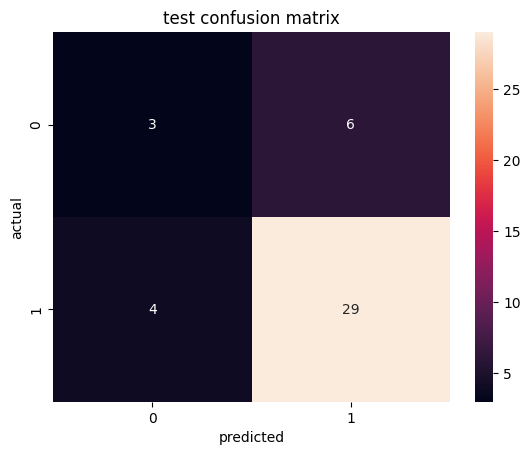

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

svc_model = SVC(C=0.5, kernel='rbf', gamma=1)
svc_model.fit(X_train, y_train)
prediction_t = svc_model .predict(X_train)
prediction = svc_model .predict(X_test)
# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))
from sklearn.metrics import f1_score
print ("F1 score train : ", f1_score(y_train, prediction_t,average="macro"))
print ("F1 score test: ", f1_score(y_test, prediction,average="macro"))
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

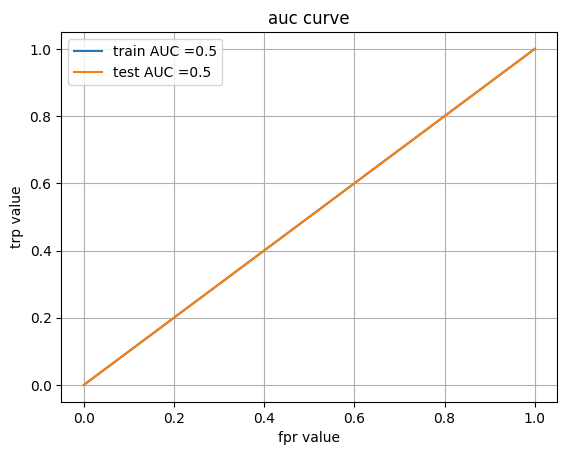

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, prediction_t)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, prediction)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
gbdt=XGBClassifier()
parameters ={"max_depth":[3,4,5,6,7],"n_estimators":[10,50,100,150,200]}
clf1 = GridSearchCV(gbdt, parameters, cv=4,n_jobs=-1,scoring='f1_macro',return_train_score=True)
clf1.fit(X_train, y_train)
clf1.best_estimator_.get_params()

{'objective': 'binary:logistic',
 'use_label_encoder': None,
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'gpu_id': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 4,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'n_estimators': 10,
 'n_jobs': None,
 'num_parallel_tree': None,
 'predictor': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

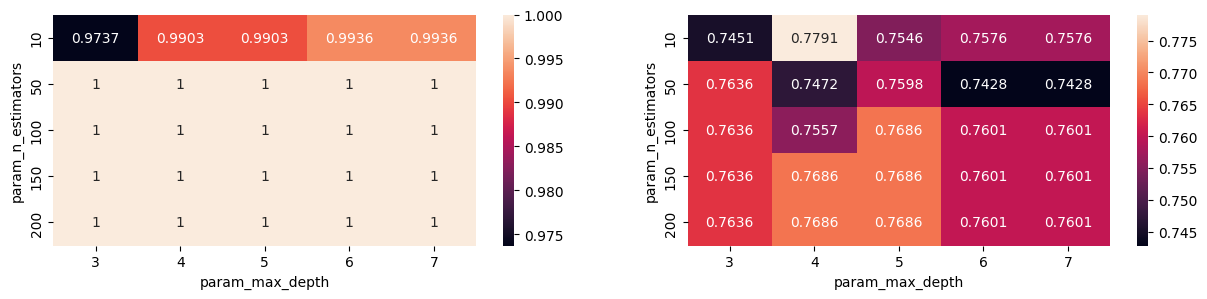

In [ ]:
import pandas as pd
import seaborn as sn
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
result=pd.DataFrame.from_dict(clf1.cv_results_)
max_score=result.groupby(["param_n_estimators","param_max_depth"]).max()
max_score=max_score.unstack()[["mean_test_score","mean_train_score"]]
a=sn.heatmap(max_score.mean_train_score,annot=True,fmt=".4g")
b=fig.add_subplot(122)
a=sn.heatmap(max_score.mean_test_score,annot=True,fmt=".4g")

In [ ]:
def batch_predict(clf, data):
    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs

    y_data_pred = []
    tr_loop = data.shape[0] - data.shape[0]%1000
    for i in range(0, tr_loop, 1000):
        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])
    # we will be predicting for the last data points
    if data.shape[0]%1000 !=0:
        y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])

    return y_data_pred

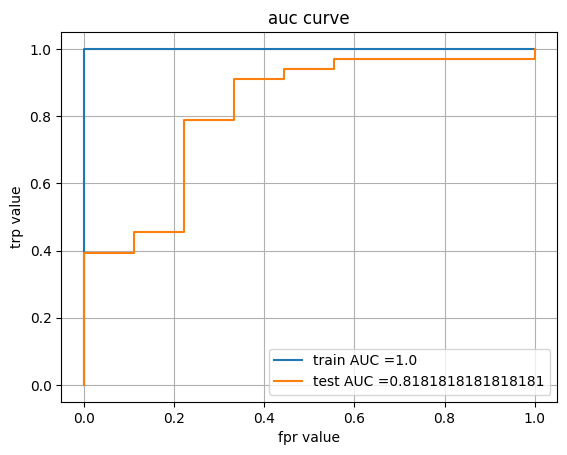

In [ ]:
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
gbdt1 = XGBClassifier(max_depth=3,n_estimators=150)
gbdt1.fit(X_train, y_train)

y_train_pred1 = batch_predict(gbdt1, X_train)
y_test_pred1= batch_predict(gbdt1, X_test)

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred1)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred1)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
def find_best_threshold(threshould, fpr, tpr):
    t = threshould[np.argmax(tpr*(1-fpr))]
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    #print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

def predict_with_best_t(proba, threshould):
    predictions = []
    for i in proba:
        if i>=threshould:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

Text(792.3131313131312, 0.5, 'actual')

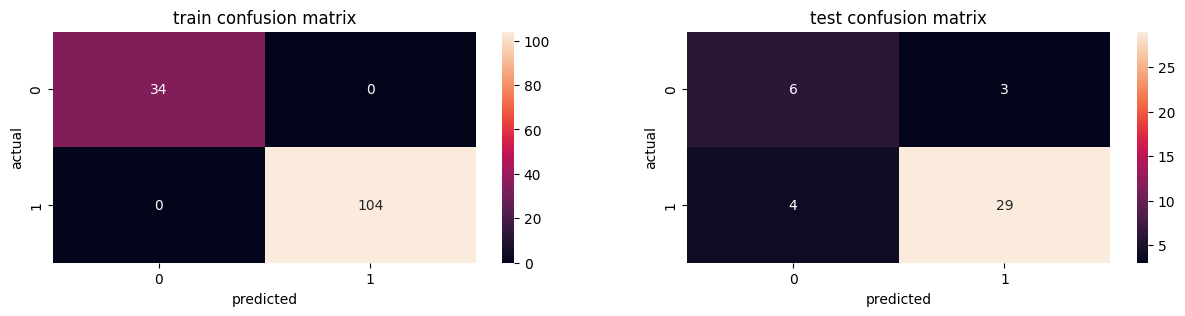

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
k=confusion_matrix(y_train, predict_with_best_t(y_train_pred1, best_t))
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
a=sn.heatmap(k,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
a.set_title("train confusion matrix")
a.set_xlabel("predicted")
a.set_ylabel("actual")
b=fig.add_subplot(122)
y_pred=predict_with_best_t(y_test_pred1, best_t)
c_test=confusion_matrix(y_test, y_pred)
b=sn.heatmap(c_test,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
print(accuracy_score(y_train, predict_with_best_t(y_train_pred1, best_t)))
print(accuracy_score(y_test, predict_with_best_t(y_test_pred1, best_t)))

from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

1.0
0.8333333333333334
f1_score train :  0.9167922821826952
f1_score test:  0.7619433198380566


In [ ]:
a=X_test[10:11]

In [ ]:
print("ground truth",y_test[10])

ground truth 1


In [ ]:
if gbdt1.predict(a)[0]==1:
  print("disease")
else:
  print("healthy")

disease


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dense, Dropout
from keras.regularizers import l2
from keras.optimizers import Adam
input_dim = x.shape[1]
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=input_dim))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split
x = np.asarray(standardized_X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.23, random_state=42)
import numpy as np

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1,validation_data=(X_test, y_test))

# # Evaluate the model
# loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
# print('Test loss:', loss)
# print('Test accuracy:', accuracy)

In [ ]:
from keras.callbacks import TensorBoard

# Create a TensorBoard callback
tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)

# Train the model
history = model.fit(X_train, y_train, epochs=12, batch_size=16, verbose=1,
                    validation_data=(X_test, y_test), callbacks=[tensorboard_callback])

Epoch 1/12
9/9 [==============================] - 7s 64ms/step - loss: 1.0278 - accuracy: 0.5000 - val_loss: 0.8587 - val_accuracy: 0.7857
Epoch 2/12
9/9 [==============================] - 0s 19ms/step - loss: 0.8592 - accuracy: 0.7464 - val_loss: 0.8779 - val_accuracy: 0.7857
Epoch 3/12
9/9 [==============================] - 0s 17ms/step - loss: 0.7932 - accuracy: 0.7536 - val_loss: 0.9109 - val_accuracy: 0.7857
Epoch 4/12
9/9 [==============================] - 0s 16ms/step - loss: 0.7654 - accuracy: 0.7609 - val_loss: 0.9385 - val_accuracy: 0.7857
Epoch 5/12
9/9 [==============================] - 0s 17ms/step - loss: 0.7297 - accuracy: 0.7826 - val_loss: 0.9381 - val_accuracy: 0.8095
Epoch 6/12
9/9 [==============================] - 0s 17ms/step - loss: 0.6864 - accuracy: 0.7899 - val_loss: 0.9507 - val_accuracy: 0.8095
Epoch 7/12
9/9 [==============================] - 0s 19ms/step - loss: 0.6550 - accuracy: 0.8406 - val_loss: 0.9393 - val_accuracy: 0.8333
Epoch 8/12
9/9 [===========

In [ ]:
!kill 5452
%reload_ext tensorboard
%tensorboard --logdir logs

In [ ]:
model.evaluate(X_train, y_train)[1]
model.evaluate(X_test, y_test)[1]

2/2 [==============================] - 0s 8ms/step - loss: 0.9547 - accuracy: 0.8571


0.8571428656578064

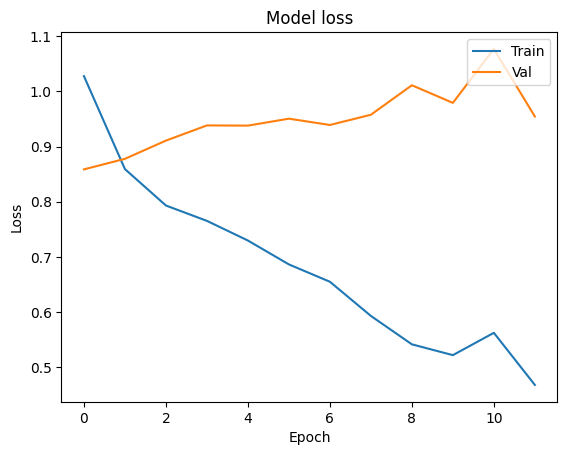

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

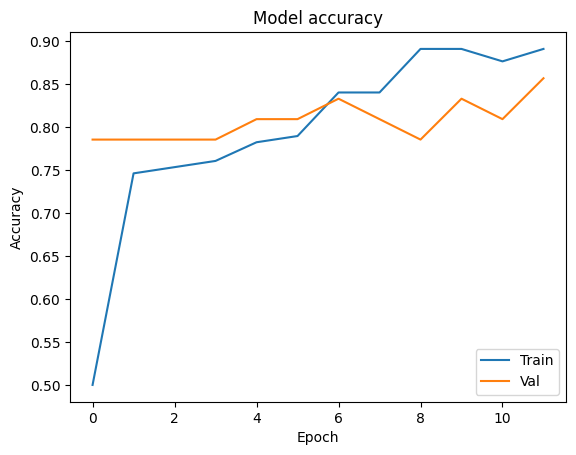

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
if model.predict(X_test[5:6])[0][0]<0.5:
  print("healthy")
else:
  print("disease")

1/1 [==============================] - 0s 95ms/step
disease


In [ ]:
def predict_with_best_t(proba):
    predictions = []
    for i in proba:
        if i>=0.5:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

In [ ]:
y_tpred=model.predict(X_train)
y_pred=model.predict(X_test)

2/2 [==============================] - 0s 6ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predict_with_best_t(y_pred))
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[ 6  3]
 [ 3 30]]


Text(50.722222222222214, 0.5, 'actual')

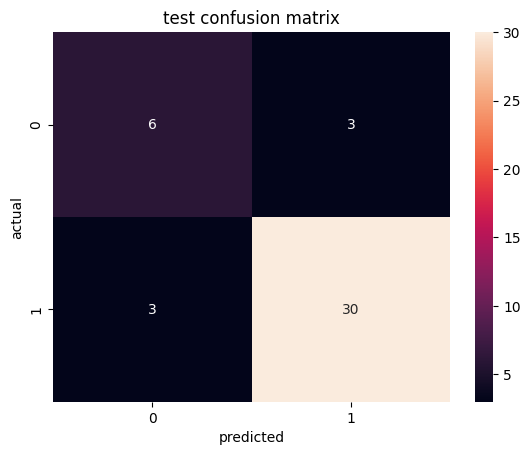

In [ ]:
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

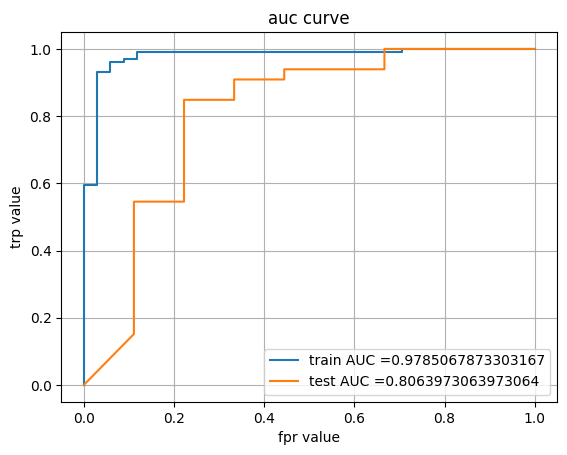

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, predict_with_best_t(y_pred)))
print('Recall: %.3f' % recall_score(y_test, predict_with_best_t(y_pred)))

Precision: 0.909
Recall: 0.909
